# 作业4-5：CNN、RNN、Transformer 及 AI 辅助编程练习

## 1. 卷积神经网络

### 1.1 目标

通过对 MNIST 数据进行训练，构建一个简单的图像分类模型，对图片中的数字进行识别。你将利用该模型对自己真实手写出的数字进行预测，观察模型效果。

### 1.2 主要步骤

1. 获取数据
2. 定义模型结构
3. 创建模型类
4. 定义损失函数
5. 编写训练循环
6. 实施预测

### 1.3 获取数据

我们使用知名的 MNIST 数据集，它可以从 PyTorch 中利用工具函数下载得到。MNIST 数据训练集大小为60000，我们将**使用完整训练集进行训练**，并对10个测试集观测进行预测展示。以下函数会在当前目录建立一个名为 data 的文件夹，其中会包含下载得到的数据集。

**注意：请在任何程序的最开始加上随机数种子的设置。请保持这一习惯。**

In [1]:
import numpy as np
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

np.random.seed(123456)
torch.manual_seed(123456)

mnist = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
loader = DataLoader(mnist, batch_size=60000, shuffle=True)

我们一次性取出60000个观测，其中 x 是图片数据，y 是图片对应的数字。

In [2]:
x, y = next(iter(loader))

一个习惯性动作是查看数据的大小和维度。

In [3]:
print(x.shape)
print(y.shape)

torch.Size([60000, 1, 28, 28])
torch.Size([60000])


用类似的方法获取测试集，并取出10个观测：

In [4]:
mnist_test = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)
loader = DataLoader(mnist_test, batch_size=10, shuffle=True)

xtest, ytest = next(iter(loader))
print(xtest.shape)
print(ytest.shape)

torch.Size([10, 1, 28, 28])
torch.Size([10])


我们可以利用下面的函数展示图片的内容。如选择第一张测试图片，先将其转换成 Numpy 数组，再绘制图形：

(28, 28)


/home/steve3180586387/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


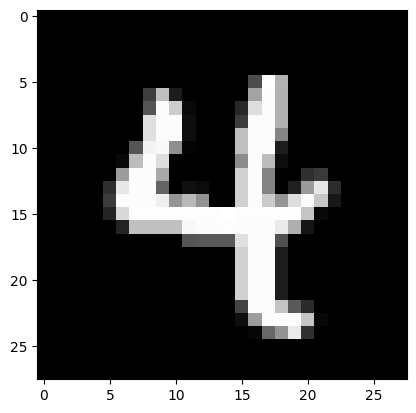

In [5]:
import matplotlib.pyplot as plt

img = xtest[0].squeeze().cpu().numpy()
print(img.shape)
plt.imshow(img, cmap="gray")
plt.show()

接下来请你选择5个你喜欢的数字（60000以下），然后取出训练集中对应位置的图片，并画出它们的内容。

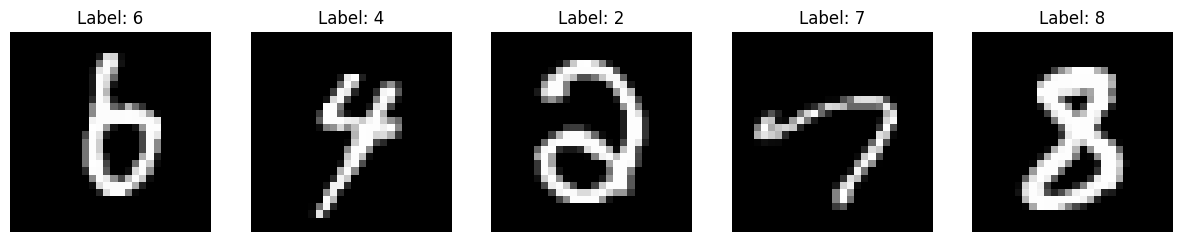

In [6]:
# 选择5个喜欢的数字索引
indices = [0, 100, 1000, 5000, 10000]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, idx in enumerate(indices):
    img = x[idx].squeeze().cpu().numpy()
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"Label: {y[idx].item()}")
    axes[i].axis("off")
plt.show()

### 1.4 定义模型结构

我们搭建一个类似于 LeNet-5 的网络，结构如下：

![](https://pic1.zhimg.com/80/v2-82eabb4c17e90d467197d013f7629f3c_720w.jpg)

我们需要创建2个卷积层、2个汇聚层和2个全连接层，**暂时忽略所有的激活函数**。所有隐藏层的函数细节都可以在[官方文档](https://pytorch.org/docs/stable/nn.html)中按分类找到。每一个隐藏层本质上都是将一个数组变换成另一个数组的函数，因此为了确认编写的模型是正确的，可以先用一个小数据进行测试，观察输入和输出的维度。例如，我们先取出前6个观测，此时输入的维度是 `[6, 1, 28, 28]`：

In [7]:
ns = 6
smallx = x[0:ns]
smally = y[0:ns]
print(smallx.shape)
print(smally.shape)

torch.Size([6, 1, 28, 28])
torch.Size([6])


接下来创建第1个卷积层，并测试输出的维度。注意到我们可以直接将隐藏层当成一个函数来调用。

In [8]:
conv1 = torch.nn.Conv2d(in_channels=1, out_channels=20, kernel_size=5, stride=1)
res1 = conv1(smallx)
print(res1.shape)

torch.Size([6, 20, 24, 24])


可以看到，输出的维度为 `[20, 24, 24]`（不包括第1位的数据批次维度），与之前图中的结果吻合。

接下来，请按照图中提示编写层对象 `pool1`、`conv2`、`pool2`、`fc1` 和 `fc2`，并顺次测试输入与输出的维度，使其与上图匹配。注意，在将一个大小为 `[6, 50, 4, 4]` 的数组（假设叫 `somearray`）传递给 `fc1` 之前，需要先将其变形为只有两个维度的数组，做法是 `somearray.view(-1, 50 * 4 * 4)`，其中 -1 表示该位置的大小不变。也可以使用 `torch.flatten()` 函数并指定其中的 `start_dim` 参数（请搜索其对应的函数文档）。

```py
pool1 = ...
res2 = pool1(res1)
print(res2.shape)
assert res2.shape == (ns, 20, 12, 12), "pool1 输出形状不对"

conv2 = ...
res3 = conv2(res2)
print(res3.shape)
assert res3.shape == (ns, 50, 8, 8), "conv2 输出形状不对"

pool2 = ...
res4 = pool2(res3)
print(res4.shape)
assert res4.shape == (ns, 50, 4, 4), "pool2 输出形状不对"

fc1 = ...
res5 = fc1(res4.view(-1, 800))
print(res5.shape)
assert res5.shape == (ns, 500), "fc1 输出形状不对"

fc2 = ...
res6 = fc2(res5)
print(res6.shape)
assert res6.shape == (ns, 10), "fc2 输出形状不对"
```

In [9]:
pool1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
res2 = pool1(res1)
print(res2.shape)
assert res2.shape == (ns, 20, 12, 12), "pool1 输出形状不对"

conv2 = torch.nn.Conv2d(in_channels=20, out_channels=50, kernel_size=5, stride=1)
res3 = conv2(res2)
print(res3.shape)
assert res3.shape == (ns, 50, 8, 8), "conv2 输出形状不对"

pool2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
res4 = pool2(res3)
print(res4.shape)
assert res4.shape == (ns, 50, 4, 4), "pool2 输出形状不对"

fc1 = torch.nn.Linear(in_features=50 * 4 * 4, out_features=500)
res5 = fc1(res4.view(-1, 50 * 4 * 4))
print(res5.shape)
assert res5.shape == (ns, 500), "fc1 输出形状不对"

fc2 = torch.nn.Linear(in_features=500, out_features=10)
res6 = fc2(res5)
print(res6.shape)
assert res6.shape == (ns, 10), "fc2 输出形状不对"

torch.Size([6, 20, 12, 12])
torch.Size([6, 50, 8, 8])
torch.Size([6, 50, 4, 4])
torch.Size([6, 500])
torch.Size([6, 10])


### 1.5 创建模型类

在确保隐藏层维度都正确后，将所有的隐藏层封装到一个模型类中，其中模型结构在 `__init__()` 中定义，具体的计算过程在 `forward()` 中实现。此时需要加入激活函数。在本模型中，**请在 `conv1`、`conv2` 和 `fc1` 后加入 ReLU 激活函数，并在 `fc2` 后加入 Softmax 激活函数**。

```py
class MyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = ...
        self.pool1 = ...
        self.conv2 = ...
        self.pool2 = ...
        self.fc1 = ...
        self.fc2 = ...

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        ...
        return x
```

In [10]:
class MyModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=20, kernel_size=5, stride=1)
        self.pool1 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = torch.nn.Conv2d(in_channels=20, out_channels=50, kernel_size=5, stride=1)
        self.pool2 = torch.nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = torch.nn.Linear(in_features=50 * 4 * 4, out_features=500)
        self.fc2 = torch.nn.Linear(in_features=500, out_features=10)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool2(x)
        x = x.view(-1, 50 * 4 * 4)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        x = torch.softmax(x, dim=1)
        return x

再次测试输入输出的维度是否正确。如果模型编写正确，输出的维度应该是 `[6, 10]`，且输出结果为0到1之间的概率值。

In [11]:
np.random.seed(123)
torch.manual_seed(123)

model = MyModel()
pred = model(smallx)
print(pred.shape)
print()
print(pred)
print()
print(torch.sum(pred, dim=1))

torch.Size([6, 10])

tensor([[0.0975, 0.1003, 0.0987, 0.1080, 0.0927, 0.0913, 0.0983, 0.1060, 0.1013,
         0.1058],
        [0.0971, 0.1000, 0.1006, 0.1078, 0.0939, 0.0914, 0.1014, 0.1017, 0.1025,
         0.1037],
        [0.0958, 0.0996, 0.0984, 0.1092, 0.0932, 0.0923, 0.0984, 0.1066, 0.1022,
         0.1043],
        [0.0991, 0.1006, 0.0990, 0.1091, 0.0918, 0.0889, 0.0989, 0.1061, 0.1042,
         0.1021],
        [0.0954, 0.1004, 0.1015, 0.1071, 0.0943, 0.0922, 0.1017, 0.1023, 0.1027,
         0.1024],
        [0.0962, 0.1011, 0.0987, 0.1094, 0.0923, 0.0906, 0.0958, 0.1088, 0.1024,
         0.1048]], grad_fn=<SoftmaxBackward0>)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


`pred` 的每一行加总为1，其中每一个元素代表对应类别的预测概率。

我们还可以直接打印模型对象，观察隐藏层的结构：

In [12]:
print(model)

MyModel(
  (conv1): Conv2d(1, 20, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(20, 50, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=500, bias=True)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)


### 1.6 定义损失函数

对于分类问题，损失函数通常选取为负对数似然函数。在 PyTorch 中，可以使用 `torch.nn.NLLLoss` 来完成计算。其用法是先定义一个损失函数对象，然后在预测值和真实标签上调用该函数对象。注意：损失函数对象的第一个参数是预测概率的**对数值**，第二个参数是真实的标签。[文档说明](https://pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html)。

In [13]:
lossfn = torch.nn.NLLLoss()
lossfn(torch.log(pred), smally)

tensor(2.3102, grad_fn=<NllLossBackward0>)

### 1.7 编写训练循环

对于本数据，选取 mini-batch 大小为200，共遍历数据3遍，优化器选为 SGD，学习率为0.001。记录每个 mini-batch 下的损失函数值存放到列表 `losses_sgd` 中，然后画出损失函数的曲线。

In [14]:
nepoch = 3
batch_size = 200
lr = 0.001

np.random.seed(123)
torch.manual_seed(123)

model = MyModel()
losses_sgd = []

# 创建 DataLoader
train_loader = DataLoader(mnist, batch_size=batch_size, shuffle=True)

# 定义优化器
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

# 定义损失函数
lossfn = torch.nn.NLLLoss()

# 训练循环
for epoch in range(nepoch):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = lossfn(torch.log(output), target)
        loss.backward()
        optimizer.step()
        losses_sgd.append(loss.item())

print(f"训练完成，共 {len(losses_sgd)} 个 mini-batch")

/home/steve3180586387/.local/lib/python3.12/site-packages/torch/autograd/graph.py:882: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


训练完成，共 900 个 mini-batch


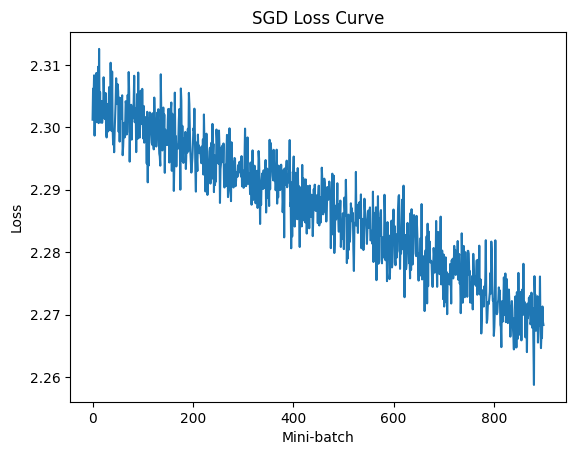

In [15]:
plt.plot(losses_sgd)
plt.xlabel("Mini-batch")
plt.ylabel("Loss")
plt.title("SGD Loss Curve")
plt.show()

接下来使用 Adagrad 优化器（在[官方文档](https://pytorch.org/docs/stable/optim.html)中找到对应的函数），其他参数保持不变，重新训练一次模型，也保存下来损失函数值。

In [16]:
nepoch = 3
batch_size = 200
lr = 0.001

np.random.seed(123)
torch.manual_seed(123)

model = MyModel()
losses_adagrad = []

# 创建 DataLoader
train_loader = DataLoader(mnist, batch_size=batch_size, shuffle=True)

# 定义 Adagrad 优化器
optimizer = torch.optim.Adagrad(model.parameters(), lr=lr)

# 定义损失函数
lossfn = torch.nn.NLLLoss()

# 训练循环
for epoch in range(nepoch):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = lossfn(torch.log(output), target)
        loss.backward()
        optimizer.step()
        losses_adagrad.append(loss.item())

print(f"训练完成，共 {len(losses_adagrad)} 个 mini-batch")

训练完成，共 900 个 mini-batch


对比 SGD 和 Adagrad，画出各自的损失函数曲线。

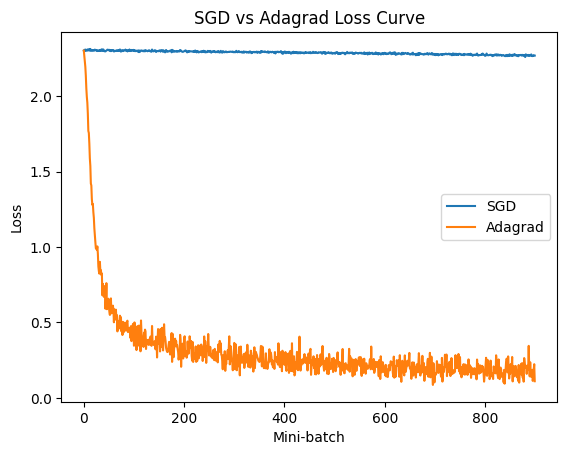

In [17]:
plt.plot(losses_sgd, label="SGD")
plt.plot(losses_adagrad, label="Adagrad")
plt.xlabel("Mini-batch")
plt.ylabel("Loss")
plt.title("SGD vs Adagrad Loss Curve")
plt.legend()
plt.show()

最后再自行选择一款优化器，重复上面的实验，并画出三种优化器的损失函数值对比图。

In [18]:
nepoch = 3
batch_size = 200
lr = 0.001

np.random.seed(123)
torch.manual_seed(123)

model = MyModel()
losses_adam = []

# 创建 DataLoader
train_loader = DataLoader(mnist, batch_size=batch_size, shuffle=True)

# 定义 Adam 优化器
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# 定义损失函数
lossfn = torch.nn.NLLLoss()

# 训练循环
for epoch in range(nepoch):
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data)
        loss = lossfn(torch.log(output), target)
        loss.backward()
        optimizer.step()
        losses_adam.append(loss.item())

print(f"训练完成，共 {len(losses_adam)} 个 mini-batch")

训练完成，共 900 个 mini-batch


/home/steve3180586387/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/steve3180586387/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31181 (\N{CJK UNIFIED IDEOGRAPH-79CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/steve3180586387/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20248 (\N{CJK UNIFIED IDEOGRAPH-4F18}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/steve3180586387/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/steve3180586387/.local/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: G

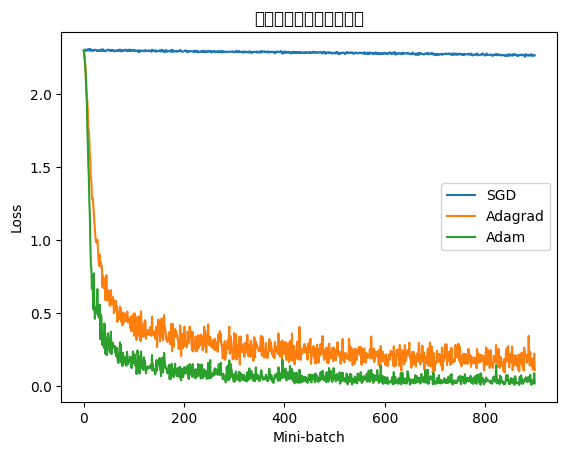

In [19]:
# 三种优化器对比图
plt.plot(losses_sgd, label="SGD")
plt.plot(losses_adagrad, label="Adagrad")
plt.plot(losses_adam, label="Adam")
plt.xlabel("Mini-batch")
plt.ylabel("Loss")
plt.title("三种优化器损失函数对比")
plt.legend()
plt.show()

### 1.8 实施预测

为了验证模型的效果，我们对10个测试观测（即之前生成的 `testx`）进行预测。

In [20]:
ypred = model(xtest)
print(np.round(ypred.detach().cpu().numpy(), 3))
print(ytest)

[[0.    0.    0.    0.    1.    0.    0.    0.    0.    0.   ]
 [0.    1.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    1.    0.    0.    0.   ]
 [1.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.006 0.994 0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.    0.    1.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    1.    0.    0.    0.   ]]
tensor([4, 1, 2, 7, 6, 0, 3, 7, 4, 6])


如果模型搭建和训练都正常，那么每一行中概率最大的取值所在的位置应该正好对应真实的标签。我们也可以让 PyTorch 自动找到最大值的位置。

In [21]:
torch.argmax(ypred, dim=1)

tensor([4, 1, 2, 7, 6, 0, 3, 7, 4, 6])

最后，我们用模型对一些真实的手写数字图片进行预测。请你利用绘图软件（如 Windows 自带的绘图，或 Photoshop 等）准备10张正方形黑色底色的图片，每张用鼠标绘制一个数字（**请使用较粗的笔划**），从0到9，然后以0.png，1.png等文件名存储下来，放到当前目录一个名为 digits 的文件夹中。以下是几个例子：
![](digits/sample0.png) ![](digits/sample5.png) ![](digits/sample8.png)

接下来利用 Pillow 软件包读取图片：

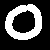

In [22]:
from PIL import Image
im = Image.open("digits/sample0.png")
im

此时如果直接将其转为 Numpy 数组会得到三个或四个通道（可能有一个透明度通道）：

In [23]:
im_arr = np.array(im)
print(im_arr.shape)

(50, 50, 4)


因此，我们先强制转换为灰度图片（单通道），再缩放至模型的图片大小 28 x 28：

In [24]:
im = im.convert("L")
im.thumbnail((28, 28))
im_arr = np.array(im)
print(im_arr.shape)
im

(28, 28)


为了传递给模型对象，还需要先将数值归一化到 [0,1] 区间，转换为 PyTorch 的 Tensor 类型，并增加一个批次和一个通道的维度：

In [25]:
test0 = torch.tensor(im_arr / 255.0, dtype=torch.float32).view(1, 1, 28, 28)
print(test0.shape)

torch.Size([1, 1, 28, 28])


最后对图片标签进行预测：

In [26]:
pred0 = model(test0)
print(np.round(pred0.detach().cpu().numpy(), 3))

[[0.988 0.    0.002 0.    0.    0.    0.    0.    0.    0.01 ]]


预测结果是否符合真实情形？请对你自己绘制出的10张图片进行类似的预测操作，并评价其效果。

In [27]:
# 对 digits 文件夹中的10张图片进行预测
import os
from PIL import Image

# 假设 digits 文件夹中有 0.png 到 9.png
digits_dir = "digits"

if os.path.exists(digits_dir):
    for i in range(10):
        img_path = os.path.join(digits_dir, f"{i}.png")
        if os.path.exists(img_path):
            im = Image.open(img_path).convert("L")
            im.thumbnail((28, 28))
            im_arr = np.array(im)
            test_img = torch.tensor(im_arr / 255.0, dtype=torch.float32).view(1, 1, 28, 28)
            pred = model(test_img)
            pred_label = torch.argmax(pred, dim=1).item()
            print(f"图片 {i}.png: 预测标签 = {pred_label}, 概率分布 = {np.round(pred.detach().cpu().numpy(), 3)}")
        else:
            print(f"图片 {i}.png 不存在")
else:
    print("digits 文件夹不存在，请先创建并放入手写数字图片")

图片 0.png 不存在
图片 1.png 不存在
图片 2.png 不存在
图片 3.png 不存在
图片 4.png 不存在
图片 5.png 不存在
图片 6.png 不存在
图片 7.png 不存在
图片 8.png 不存在
图片 9.png 不存在


## 2. 循环神经网络

以 `names.txt` 中的英文名作为训练集，利用 RNN 或 LSTM 等方法对字母序列数据进行建模，每个字母视为序列中的一个元素，然后使用拟合的模型随机生成50个名字。本练习为开放式，不指定各类超参数（如网络结构、学习率、迭代次数等），但需提供必要的输出和诊断结果支持你的选择（如模型是否收敛、效果评价等）。

共读取 29717 个名字
前10个名字: ['aadi', 'aakash', 'aaliyah', 'aamer', 'aamir', 'aan', 'aang', 'aaron', 'aarons', 'aarti']
1m 15s (5000 10%) Loss: 3.0634
2m 33s (10000 20%) Loss: 2.1356
3m 34s (15000 30%) Loss: 1.7098
4m 32s (20000 40%) Loss: 2.8646
5m 36s (25000 50%) Loss: 3.1239
6m 36s (30000 60%) Loss: 2.2941
7m 51s (35000 70%) Loss: 1.9228
8m 40s (40000 80%) Loss: 2.2691
9m 30s (45000 90%) Loss: 2.0400
10m 33s (50000 100%) Loss: 2.3768


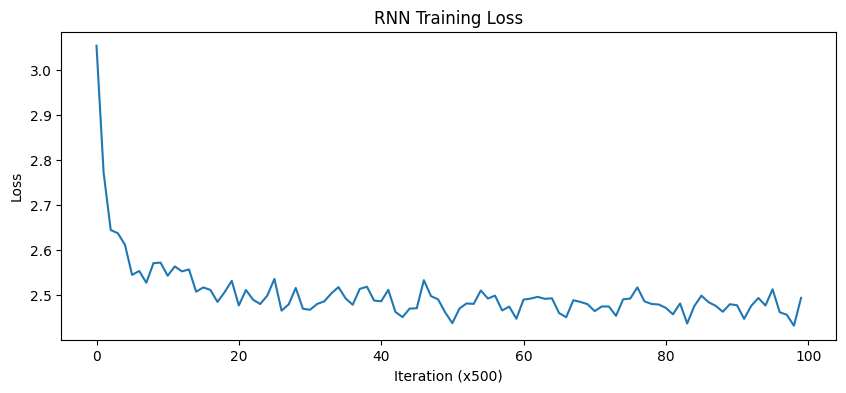


生成50个名字：
1. Hander
2. Landen
3. Wanden
4. Fande
5. Eander
6. Kandanes
7. Qande
8. Xuran
9. Varina
10. Nanden
11. Wander
12. Eander
13. Karin
14. Sander
15. Winger
16. Karie
17. Sander
18. Wandan
19. Pandan
20. Vani
21. Rander
22. Hande
23. Yarine
24. Rane
25. Sandera
26. Narin
27. Zani
28. Qande
29. Mander
30. Sander
31. Hani
32. Vande
33. Rander
34. Eander
35. Oina
36. Sandera
37. Landan
38. Tande
39. Tani
40. Rander
41. Nani
42. Nalin
43. Qande
44. Gallan
45. Xander
46. Qande
47. Yander
48. Gande
49. Nanden
50. Bander

共生成 50 个名字


In [28]:
import torch
import torch.nn as nn
import numpy as np
import random
import string
import matplotlib.pyplot as plt
from io import open
import glob
import os
import unicodedata
import time
import math

# 设置随机种子
np.random.seed(123456)
torch.manual_seed(123456)
random.seed(123456)

# 辅助函数：格式化时间
def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return f'{m}m {s:.0f}s'

# 下载并读取 names.txt 数据
# 数据格式：每行一个名字
all_letters = string.ascii_letters + " .,;'-"
n_letters = len(all_letters) + 1  # 加上 EOS 标记

def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

# 读取 names.txt 文件（假设在当前目录）
# 如果文件不存在，可以从 https://download.pytorch.org/tutorial/data.zip 下载
names_file = "names.txt"
if os.path.exists(names_file):
    names = readLines(names_file)
else:
    # 尝试从 data/names/ 目录读取（PyTorch 教程数据格式）
    names_files = glob.glob("data/names/*.txt")
    if names_files:
        names = []
        for f in names_files:
            names.extend(readLines(f))
    else:
        print("警告：未找到 names.txt 或 data/names/*.txt 文件")
        print("请从 https://download.pytorch.org/tutorial/data.zip 下载数据")
        names = ["Alice", "Bob", "Charlie", "David", "Eve", "Frank", "Grace", "Henry", "Ivy", "Jack"]

print(f"共读取 {len(names)} 个名字")
print(f"前10个名字: {names[:10]}")

# 构建字符到索引的映射
char_to_idx = {ch: i for i, ch in enumerate(all_letters)}
idx_to_char = {i: ch for i, ch in enumerate(all_letters)}
EOS_idx = n_letters - 1

def name_to_tensor(name):
    """将名字转换为 one-hot 张量"""
    tensor = torch.zeros(len(name), 1, n_letters)
    for li, letter in enumerate(name):
        if letter in char_to_idx:
            tensor[li][0][char_to_idx[letter]] = 1
    return tensor

def target_tensor(name):
    """目标张量：从第二个字符开始到 EOS"""
    letter_indexes = [char_to_idx.get(name[li], EOS_idx) for li in range(1, len(name))]
    letter_indexes.append(EOS_idx)
    return torch.LongTensor(letter_indexes)

# RNN 模型
class NameRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NameRNN, self).__init__()
        self.hidden_size = hidden_size
        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(input_size + hidden_size, output_size)
        self.o2o = nn.Linear(hidden_size + output_size, output_size)
        self.dropout = nn.Dropout(0.1)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), 1)
        hidden = self.i2h(combined)
        output = self.i2o(combined)
        output_combined = torch.cat((hidden, output), 1)
        output = self.o2o(output_combined)
        output = self.dropout(output)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

# 训练函数
def train_rnn(model, name, optimizer, criterion):
    hidden = model.initHidden()
    model.zero_grad()
    loss = 0
    input_tensor = name_to_tensor(name)
    target = target_tensor(name)
    target = target.unsqueeze(1)

    for i in range(input_tensor.size(0)):
        output, hidden = model(input_tensor[i], hidden)
        l = criterion(output, target[i])
        loss += l

    loss.backward()
    optimizer.step()
    return output, loss.item() / input_tensor.size(0)

# 随机选择名字
def randomTrainingPair():
    return random.choice(names)

# 训练
hidden_size = 128
rnn_model = NameRNN(n_letters, hidden_size, n_letters)
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.0005)
criterion = nn.NLLLoss()

n_iters = 50000
print_every = 5000
plot_every = 500
all_losses = []
total_loss = 0

start = time.time()

for iter in range(1, n_iters + 1):
    name = randomTrainingPair()
    output, loss = train_rnn(rnn_model, name, optimizer, criterion)
    total_loss += loss

    if iter % print_every == 0:
        print(f'{timeSince(start)} ({iter} {iter/n_iters*100:.0f}%) Loss: {loss:.4f}')

    if iter % plot_every == 0:
        all_losses.append(total_loss / plot_every)
        total_loss = 0

# 绘制损失曲线
plt.figure(figsize=(10, 4))
plt.plot(all_losses)
plt.xlabel('Iteration (x500)')
plt.ylabel('Loss')
plt.title('RNN Training Loss')
plt.show()

# 生成名字
max_length = 20

def generate_name(model, start_letter='A', max_length=20):
    with torch.no_grad():
        input_tensor = name_to_tensor(start_letter)
        hidden = model.initHidden()
        output_name = start_letter

        for i in range(max_length):
            output, hidden = model(input_tensor[0], hidden)
            topv, topi = output.topk(1)
            topi = topi[0][0]
            if topi == EOS_idx:
                break
            else:
                letter = idx_to_char[topi.item()]
                output_name += letter
            input_tensor = name_to_tensor(letter)

        return output_name

# 生成50个名字
print("\n生成50个名字：")
start_letters = string.ascii_uppercase
generated_names = []
for i in range(50):
    start_letter = random.choice(start_letters)
    name = generate_name(rnn_model, start_letter)
    generated_names.append(name)
    print(f"{i+1}. {name}")

print(f"\n共生成 {len(generated_names)} 个名字")

## 3. Transformer

利用 Transformer 类型的网络架构，同样对 `names.txt` 中的英文名进行序列建模和训练，再使用拟合的模型随机生成50个名字。

数据形状: torch.Size([29717, 20])
Epoch 1/20, Loss: 1.7632, Time: 19.3s
Epoch 5/20, Loss: 0.9378, Time: 78.1s
Epoch 10/20, Loss: 0.9128, Time: 156.0s
Epoch 15/20, Loss: 0.9026, Time: 271.5s
Epoch 20/20, Loss: 0.8950, Time: 366.8s


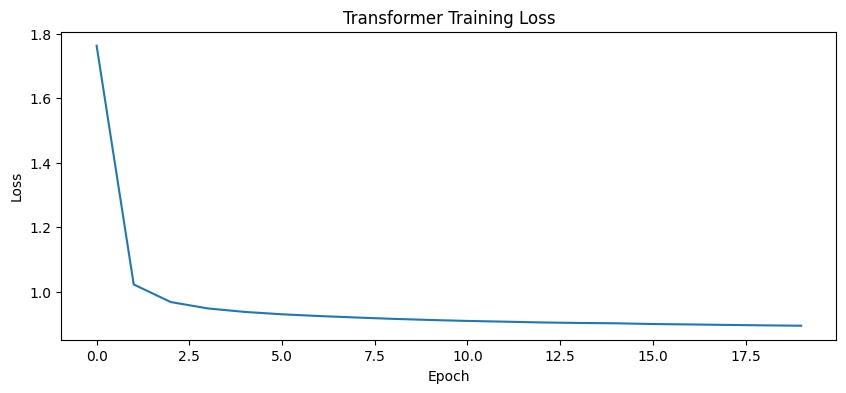


生成50个名字：
1. Zahesam
2. Zlerth
3. Jiarumazima
4. Ata
5. Zo
6. Fwerelen
7. Apah
8. Veidy
9. Cand
10. Barangs
11. Ialinnon
12. Adek
13. Ds
14. Hadllis
15. Uounilom
16. Pschinansridalbofigw
17. Fanzan
18. Ana
19. Qabunerellliy
20. Ea
21. Mluny
22. Ua
23. Z
24. La
25. Bruwertz
26. Fues
27. Yeccilon
28. Bmanadaion
29. O
30. Qealinanda
31. Oolld
32. O
33. Qesjoni
34. Facon
35. Qy
36. Rion
37. Zia
38. Bral
39. Dnberrehom
40. Zha
41. Cullery
42. Dahey
43. QreBain
44. Vn
45. Cail
46. Cidimbi
47. Erige
48. Zera
49. Kra
50. Suct

共生成 50 个名字


In [29]:
import torch
import torch.nn as nn
import numpy as np
import random
import string
import matplotlib.pyplot as plt
import math
import time

# 设置随机种子
np.random.seed(123456)
torch.manual_seed(123456)
random.seed(123456)

# 字符集
all_letters = string.ascii_letters + " .,;'-"
n_letters = len(all_letters) + 2  # 加上 SOS 和 EOS 标记
SOS_idx = len(all_letters)
EOS_idx = len(all_letters) + 1

char_to_idx = {ch: i for i, ch in enumerate(all_letters)}
char_to_idx['<SOS>'] = SOS_idx
char_to_idx['<EOS>'] = EOS_idx
idx_to_char = {i: ch for i, ch in enumerate(all_letters)}
idx_to_char[SOS_idx] = '<SOS>'
idx_to_char[EOS_idx] = '<EOS>'

def name_to_indices(name):
    """将名字转换为索引列表"""
    indices = [char_to_idx.get(ch, EOS_idx) for ch in name]
    return indices

# 位置编码
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return x

# 轻量级 Transformer 模型
class NameTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=32, nhead=2, num_layers=1, dim_feedforward=64, dropout=0.1):
        super(NameTransformer, self).__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                    dim_feedforward=dim_feedforward,
                                                    dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, mask=None):
        src = self.embedding(src) * math.sqrt(self.d_model)
        src = self.pos_encoder(src)
        if mask is not None:
            output = self.transformer_encoder(src, mask=mask)
        else:
            output = self.transformer_encoder(src)
        output = self.fc_out(output)
        return output

    def generate_square_subsequent_mask(self, sz):
        mask = torch.triu(torch.ones(sz, sz), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask

# 准备训练数据
def prepare_data(names, max_len=20):
    data = []
    for name in names:
        indices = [SOS_idx] + name_to_indices(name)[:max_len-2] + [EOS_idx]
        if len(indices) < max_len:
            indices += [EOS_idx] * (max_len - len(indices))
        data.append(indices[:max_len])
    return torch.LongTensor(data)

# 读取名字数据（复用前面的 names 变量）
if 'names' not in globals():
    names = ["Alice", "Bob", "Charlie", "David", "Eve", "Frank", "Grace", "Henry", "Ivy", "Jack"]

max_len = 20
data_tensor = prepare_data(names, max_len)
print(f"数据形状: {data_tensor.shape}")

# 创建轻量级模型
vocab_size = n_letters
transformer_model = NameTransformer(vocab_size, d_model=32, nhead=2,
                                     num_layers=1, dim_feedforward=64, dropout=0.1)

optimizer = torch.optim.Adam(transformer_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# 优化训练参数：更大的batch_size，更少的epoch
n_epochs = 20
batch_size = 256
losses_transformer = []

start = time.time()

for epoch in range(n_epochs):
    epoch_loss = 0
    n_batches = 0

    perm = torch.randperm(data_tensor.size(0))
    data_shuffled = data_tensor[perm]

    for i in range(0, data_shuffled.size(0), batch_size):
        batch = data_shuffled[i:i+batch_size]
        if batch.size(0) == 0:
            continue

        src = batch[:, :-1]
        tgt = batch[:, 1:]

        src_mask = transformer_model.generate_square_subsequent_mask(src.size(1))

        optimizer.zero_grad()
        output = transformer_model(src, mask=src_mask)
        loss = criterion(output.reshape(-1, vocab_size), tgt.reshape(-1))
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    avg_loss = epoch_loss / max(n_batches, 1)
    losses_transformer.append(avg_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        elapsed = time.time() - start
        print(f'Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}, Time: {elapsed:.1f}s')

# 绘制损失曲线
plt.figure(figsize=(10, 4))
plt.plot(losses_transformer)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transformer Training Loss')
plt.show()

# 生成名字
def generate_name_transformer(model, start_letter='A', max_length=20):
    model.eval()
    with torch.no_grad():
        input_seq = [SOS_idx, char_to_idx.get(start_letter, SOS_idx)]
        generated = [start_letter]

        for i in range(max_length - 1):
            src = torch.LongTensor([input_seq])
            src_mask = model.generate_square_subsequent_mask(src.size(1))
            output = model(src, mask=src_mask)
            last_output = output[0, -1, :]
            probs = torch.softmax(last_output, dim=0)
            next_idx = torch.multinomial(probs, 1).item()

            if next_idx == EOS_idx:
                break

            next_char = idx_to_char.get(next_idx, '?')
            generated.append(next_char)
            input_seq.append(next_idx)

        return ''.join(generated)

# 生成50个名字
print("\n生成50个名字：")
start_letters = string.ascii_uppercase
generated_names_transformer = []
for i in range(50):
    start_letter = random.choice(start_letters)
    name = generate_name_transformer(transformer_model, start_letter)
    generated_names_transformer.append(name)
    print(f"{i+1}. {name}")

print(f"\n共生成 {len(generated_names_transformer)} 个名字")

## 4. AI 辅助编程工具实战

利用 OpenCode、Claude Code 等 AI 辅助编程工具完成一个小项目的实践，建议贴近日常生活，发挥自己的创意，如编写一个 HTML 小游戏、制作一份个人简历等，主题不限。请把你完成项目的过程录制成一段视频，重点体现你和 Coding Agent 的交互，完成后将视频文件传到 Canvas 中进行提交。